In [2]:
# -----------------------------
# Imports 
# -----------------------------
from pathlib import Path
from datetime import datetime, timezone
import requests
from tqdm import tqdm
import xml.etree.ElementTree as ET

import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

import cfgrib
import copernicusmarine
import shutil
import cdsapi
import zipfile



In [41]:
# -----------------------------
# Optional: install required packages (run once if missing)
# -----------------------------
# !pip install --user requests tqdm xarray pandas matplotlib cartopy cfgrib eccodes copernicusmarine h5py
# !pip install cdsapi


Defaulting to user installation because normal site-packages is not writeable


In [3]:
# Date to download data

USER_DATE = "2023-06-01"

In [ ]:
"""
One-day download of ERAs from Copernicus climate 

- Area: Archipelago Sea
- Format: Zarr
- Variables:
    - u10 (eastward component of 10 m wind) [m/s]
    - v10 (northward component of 10 m wind) [m/s]
- Time resolution: 1-hourly
- Bounding box: 20.4–22.9°E, 59.7–60.5°N
- Loads dataset with xarray for inspection

"""
# -----------------------------
# Settings
# -----------------------------
OUTDIR = Path("data")
OUTDIR.mkdir(exist_ok=True)

dataset = "reanalysis-era5-single-levels"

request = {
    "product_type": ["reanalysis"],
    "variable": [
        "10m_u_component_of_wind",
        "10m_v_component_of_wind"
    ],
    "year": ["2023"],
    "month": [f"{m:02d}" for m in range(1, 13)],
    "day": [f"{d:02d}" for d in range(1, 32)],
    "time": [f"{h:02d}:00" for h in range(24)],
    "data_format": "grib",
    "download_format": "zip",
    "area": [60.5, 20.4, 59.7, 22.9],  # N, W, S, E
}

zipfile_path = OUTDIR / "era5_wind_2023.zip"
grib_dir = OUTDIR / "era5_grib"

# -----------------------------
# Download data if not already
# -----------------------------
if not zipfile_path.exists():
    print("Downloading ERA5 wind data for 2023...")
    client = cdsapi.Client()
    client.retrieve(dataset, request).download(str(zipfile_path))
    print("Download complete.")
else:
    print(f"Using existing file: {zipfile_path}")

# -----------------------------
# Unzip GRIB files
# -----------------------------
grib_dir.mkdir(exist_ok=True)
with zipfile.ZipFile(zipfile_path, "r") as zip_ref:
    zip_ref.extractall(grib_dir)
print(f"Extracted GRIB files to {grib_dir}")

# -----------------------------
# Load GRIB files with xarray
# -----------------------------
grib_files = list(grib_dir.glob("*.grib*"))

ds = xr.open_mfdataset(
    grib_files,
    engine="cfgrib",
    combine="by_coords"
)

# -----------------------------
# Compute wind speed and direction
# -----------------------------
u10 = ds["u10"]
v10 = ds["v10"]

ds["wind_speed"] = np.sqrt(u10**2 + v10**2)
ds["wind_dir"] = (270 - np.rad2deg(np.arctan2(v10, u10))) % 360

# -----------------------------
# Inspect dataset
# -----------------------------
print(ds)


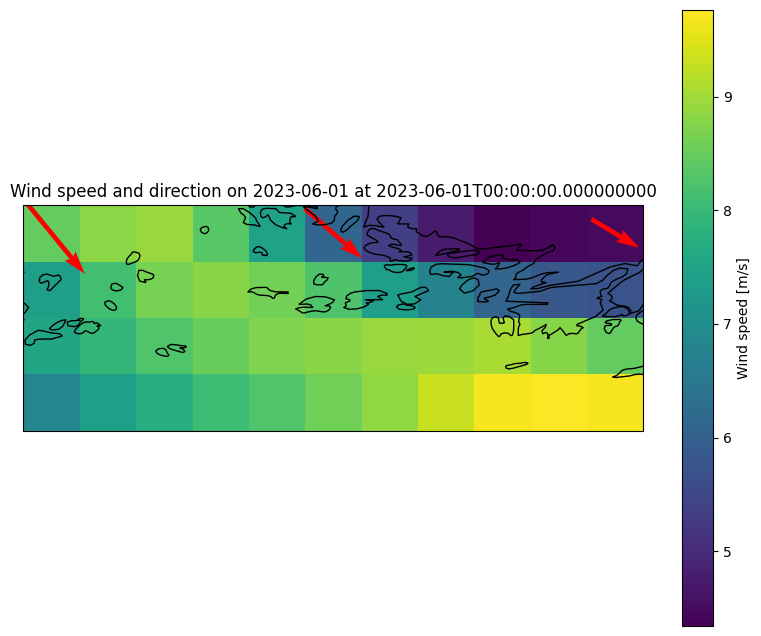

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -----------------------------
# Specify the day to plot
# -----------------------------
USER_DATE = "2023-06-01"
ds_day = ds.sel(time=slice(f"{USER_DATE}T00:00:00", f"{USER_DATE}T23:00:00"))

# Select a single time (first hour)
ds_slice = ds_day.isel(time=0)

# Extract coordinates and wind components
lons = ds_slice.longitude
lats = ds_slice.latitude
u = ds_slice.u10
v = ds_slice.v10
wind_speed = ds_slice.wind_speed

# Downsample for quiver plot
step = 5
lons_q = lons[::step]
lats_q = lats[::step]
u_q = u[::step, ::step]
v_q = v[::step, ::step]

# -----------------------------
# Plot with Cartopy
# -----------------------------
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot wind speed
cf = ax.pcolormesh(lons, lats, wind_speed, shading='auto', cmap='viridis')

# Plot wind vectors
ax.quiver(lons_q, lats_q, u_q, v_q, scale=50, color='red', pivot='middle')

# Add land, coastlines
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE)

# Colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='vertical', label='Wind speed [m/s]')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Wind speed and direction on {USER_DATE} at {str(ds_slice.time.values)}')
plt.show()


In [14]:
# ## Only for loading an ERA5 already downloaded 

# # -----------------------------
# # Paths
# # -----------------------------
# outdir = Path("data")
# zipfile_path = outdir / "ae0c05b4b34d69975dcb348d11bfd51.zip"  # replace with your downloaded file
# grib_dir = outdir / "era5_grib"

# # -----------------------------
# # Unzip the GRIB files
# # -----------------------------
# grib_dir.mkdir(exist_ok=True)
# with zipfile.ZipFile(zipfile_path, 'r') as zip_ref:
#     zip_ref.extractall(grib_dir)

# # -----------------------------
# # Load only .grib files (ignore .idx)
# # -----------------------------
# grib_files = list(grib_dir.glob("*.grib"))

# # Open each GRIB separately to avoid cfgrib index issues
# datasets = [
#     xr.open_dataset(f, engine='cfgrib', backend_kwargs={'indexpath': ''})
#     for f in grib_files
# ]

# # Combine along 'time' dimension
# ds = xr.concat(datasets, dim='time')

# # -----------------------------
# # Compute wind speed and direction
# # -----------------------------
# u10 = ds["u10"]
# v10 = ds["v10"]

# ds["wind_speed"] = np.sqrt(u10**2 + v10**2)
# ds["wind_dir"] = (270 - np.rad2deg(np.arctan2(v10, u10))) % 360

# # -----------------------------
# # Inspect the dataset
# # -----------------------------
# print(ds)


<xarray.Dataset> Size: 6MB
Dimensions:     (time: 8760, latitude: 4, longitude: 11)
Coordinates:
  * time        (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:00:00
  * latitude    (latitude) float64 32B 60.45 60.2 59.95 59.7
  * longitude   (longitude) float64 88B 20.4 20.65 20.9 ... 22.4 22.65 22.9
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:00:00
Data variables:
    u10         (time, latitude, longitude) float32 2MB 6.148 6.439 ... -5.12
    v10         (time, latitude, longitude) float32 2MB -2.363 -2.65 ... -2.099
    wind_speed  (time, latitude, longitude) float32 2MB 6.586 6.963 ... 5.533
    wind_dir    (time, latitude, longitude) float32 2MB 291.0 292.4 ... 67.71
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:     

In [4]:
"""
One-time download of the latest HARMONIE (MEPS) surface wind from FMI Open Data.

- Area: Archipelago Sea
- Format: NetCDF
- Forecast length: 48 hours (hourly)
- Full spatial resolution
- Format: netCDF
"""

# -----------------------------
# User-defined settings
# -----------------------------

OUTDIR = Path("data")
OUTDIR.mkdir(exist_ok=True)

# Forecast domain
BBOX = "20.4,59.7,22.9,60.5"  # lon_min,lat_min,lon_max,lat_max

# Common parameters
COMMON_PARAMS = {
    "bbox": BBOX,
    "format": "netcdf",
    "projection": "EPSG:4326",
    "timestep": "60",     # minutes
    "timesteps": "48",    # 48-hour forecast
    # Removed gridstep to get full spatial resolution
}

# -----------------------------
# HARMONIE wind download
# -----------------------------
harmonie_params = COMMON_PARAMS.copy()
harmonie_params.update({
    "producer": "harmonie_scandinavia_surface",
    "param": "windums,windvms",
})

harmonie_query = "&".join(f"{k}={v}" for k, v in harmonie_params.items())
harmonie_url = f"https://opendata.fmi.fi/download?{harmonie_query}"

outfile_wind = OUTDIR / "harmonie_wind_latest_48h.nc"
print(f"\nDownloading HARMONIE wind forecast to: {outfile_wind}")

with requests.get(harmonie_url, stream=True, timeout=300) as r:
    r.raise_for_status()
    total_size = int(r.headers.get('content-length', 0))
    chunk_size = 8192
    with open(outfile_wind, 'wb') as f, tqdm(
        total=total_size, unit='B', unit_scale=True, desc="HARMONIE wind"
    ) as pbar:
        for chunk in r.iter_content(chunk_size=chunk_size):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))
print("HARMONIE wind download complete.")

# Display wind dataset
wind_ds = xr.open_dataset("data/harmonie_wind_latest_48h.nc")
print(wind_ds)

HARMONIE wind: 1.55MB [00:01, 1.14MB/s]


HARMONIE wind download complete.
<xarray.Dataset> Size: 2MB
Dimensions:            (time: 48, lat: 36, lon: 112)
Coordinates:
  * time               (time) datetime64[ns] 384B 2026-01-28T09:00:00 ... 202...
  * lat                (lat) float32 144B 59.7 59.72 59.75 ... 60.45 60.48 60.5
  * lon                (lon) float32 448B 20.4 20.42 20.45 ... 22.85 22.88 22.9
Data variables:
    crs                int16 2B ...
    eastward_wind_23   (time, lat, lon) float32 774kB ...
    northward_wind_24  (time, lat, lon) float32 774kB ...
Attributes:
    Conventions:  CF-1.6
    title:        <title>
    institution:  fmi.fi
    source:       <producer>


In [17]:
"""
One-day download of WAM Baltic wave analysis from Copernicus Marine

- Area: Archipelago Sea
- Format: Zarr
- Variables:
    - VHM0: Significant wave height [m]
    - VMDR: Mean wave direction [degrees]
    - VTM10: Mean wave period [s]
- Time resolution: 1-hourly
- Bounding box: 20.4–22.9°E, 59.7–60.5°N
- Automatic check to avoid re-downloading existing files
- Loads dataset with xarray for inspection

"""


# USER_DATE = "2023-02-04"
OUTDIR = Path("data")
OUTDIR.mkdir(exist_ok=True)

# Bounding box: Archipelago Sea
MIN_LON, MAX_LON = 20.4, 22.9
MIN_LAT, MAX_LAT = 59.7, 60.5

# Dataset and variables
DATASET_ID = "cmems_mod_bal_wav_anfc_PT1H-i"
VARIABLES = ["VHM0", "VMDR", "VTM10"]

outfile = OUTDIR / f"copernicus_wam_{USER_DATE}.zarr"

# -----------------------------
# Download
# -----------------------------
if not outfile.exists():
    print(f"Downloading Copernicus WAM data to {outfile} ...")
    
    copernicusmarine.subset(
        dataset_id=DATASET_ID,
        variables=VARIABLES,
        minimum_longitude=MIN_LON,
        maximum_longitude=MAX_LON,
        minimum_latitude=MIN_LAT,
        maximum_latitude=MAX_LAT,
        start_datetime=f"{USER_DATE}T00:00:00",
        end_datetime=f"{USER_DATE}T23:00:00",
        output_directory=OUTDIR,
        output_filename=outfile.name,
        file_format="zarr",        # <- safe format
        disable_progress_bar=False
    )
    print("Download complete.")
else:
    print(f"File already exists: {outfile}")

# -----------------------------
# Load and check
# -----------------------------
wam_ds = xr.open_zarr(outfile)
print(wam_ds)
print("Time range:", wam_ds.time.values[[0, -1]])


INFO - 2026-01-27T15:35:37Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:

  mjosten


Copernicus Marine password:

  ········


INFO - 2026-01-27T15:35:51Z - Selected dataset version: "202311"
INFO - 2026-01-27T15:35:51Z - Selected dataset part: "default"


Download complete.
<xarray.Dataset> Size: 1MB
Dimensions:    (time: 24, latitude: 48, longitude: 90)
Coordinates:
  * time       (time) datetime64[ns] 192B 2023-06-01 ... 2023-06-01T23:00:00
  * latitude   (latitude) float32 192B 59.71 59.72 59.74 ... 60.46 60.47 60.49
  * longitude  (longitude) float32 360B 20.4 20.43 20.46 ... 22.82 22.85 22.87
Data variables:
    VHM0       (time, latitude, longitude) float32 415kB dask.array<chunksize=(12, 48, 90), meta=np.ndarray>
    VMDR       (time, latitude, longitude) float32 415kB dask.array<chunksize=(12, 48, 90), meta=np.ndarray>
    VTM10      (time, latitude, longitude) float32 415kB dask.array<chunksize=(12, 48, 90), meta=np.ndarray>
Attributes:
    Conventions:               CF-1.0
    cmems_product_id:          BALTICSEA_ANALYSISFORECAST_WAV_003_010
    easternmost_longitude:     30.2080
    grid_resolution:           1 nautical mile (ie. 0.0167 degrees northward;...
    institution:               Baltic MFC, PU Finnish Meteorological

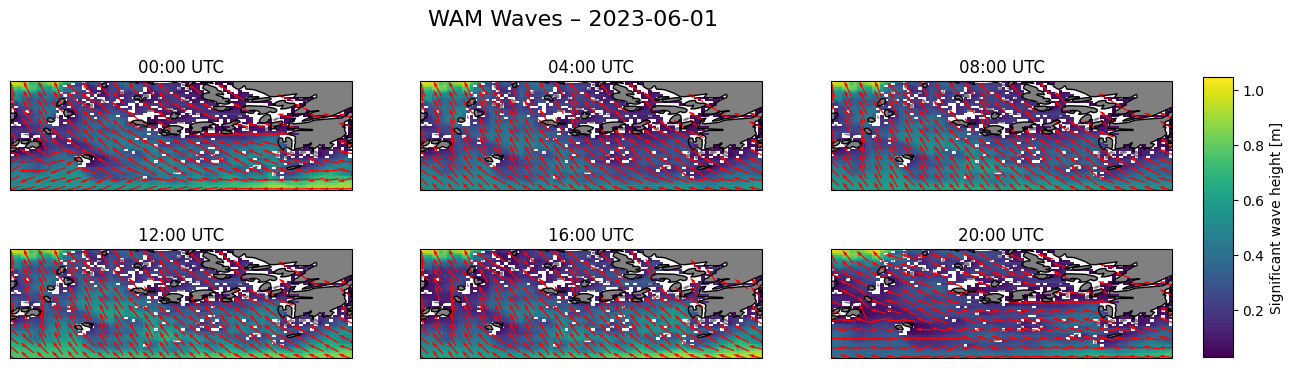

In [18]:
"""
Plot WAM Baltic wave model outputs for a single day

- Area: Archipelago Sea
- Data: Copernicus WAM (Zarr format)
- Variables: 
    - VHM0: Significant wave height [m]
    - VMDR: Mean wave direction [degrees]
- Subplots: every 4 hours (configurable)
- Features: land, coastline, wave height colormap, wave direction arrows
- Customizable:
    - USER_DATE: date to plot
    - TIME_INTERVAL_HOURS: interval between subplots
    
"""

# -----------------------------
# User settings
# -----------------------------
# USER_DATE = "2024-01-26"  # change this to plot a different day
TIME_INTERVAL_HOURS = 4    # interval between subplots

wam_file = Path(f"data/copernicus_wam_{USER_DATE}.zarr")

if not wam_file.exists():
    raise FileNotFoundError(f"WAM file not found: {wam_file}")

# # -----------------------------
# # Load WAM dataset
# # -----------------------------
# wam_ds = xr.open_zarr(wam_file)
# print("Loaded WAM dataset:", wam_file)
# print(wam_ds)

# -----------------------------
# Select times every 4 hours
# -----------------------------
times = pd.date_range(f"{USER_DATE}T00:00:00", f"{USER_DATE}T23:00:00", freq=f"{TIME_INTERVAL_HOURS}h")
n_times = len(times)

# Arrange subplots (rows x cols)
n_cols = 3
n_rows = int(np.ceil(n_times / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 2*n_rows), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# -----------------------------
# Loop over times and plot
# -----------------------------
for i, t in enumerate(times):
    ds_slice = wam_ds.sel(time=t, method="nearest")
    
    ax = axes[i]
    ax.add_feature(cfeature.LAND, facecolor='gray')
    ax.add_feature(cfeature.COASTLINE)
    
    # Significant wave height (VHM0)
    cf = ax.pcolormesh(
        ds_slice.longitude, ds_slice.latitude,
        ds_slice.VHM0,
        cmap='viridis',
        shading='auto'
    )
    
    # Mean wave direction arrows (VMDR)
    step = 4
    u = np.sin(np.deg2rad(ds_slice.VMDR.values[::step, ::step]))
    v = np.cos(np.deg2rad(ds_slice.VMDR.values[::step, ::step]))
    ax.quiver(
        ds_slice.longitude[::step],
        ds_slice.latitude[::step],
        u, v,
        scale=20, pivot='middle', color='red'
    )
    
    ax.set_title(f"{t:%H:%M UTC}")

# Remove unused axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Figure-level title
fig.suptitle(f"WAM Waves – {USER_DATE}", fontsize=16, y=1.02)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(cf, cax=cbar_ax, orientation='vertical', label='Significant wave height [m]')

# plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar and suptitle
plt.show()


In [11]:
# """
# One-time download of WAM Baltic wave forecast 

# - Area: Archipelago Sea
# - Format: GRIB2
# - Forecast length: 48 hours (hourly)
# - Option to set origintime manually or use the latest run
# """

# -----------------------------
# User can set origintime here (UTC)
# Format: "YYYY-MM-DDTHH:MM:SSZ", e.g., "2026-01-26T06:00:00Z"
# If None, use latest 00/06/12/18 UTC run
# -----------------------------

USER_ORIGINTIME = "2024-01-26T06:00:00Z"

# Output directory
OUTDIR = Path("data")
OUTDIR.mkdir(exist_ok=True)

# Bounding box: Archipelago Sea
BBOX = "20.4,59.7,22.9,60.5"

# -----------------------------
# Determine origintime
# -----------------------------
now = datetime.now(timezone.utc)
if USER_ORIGINTIME is not None:
    origintime_str = USER_ORIGINTIME
else:
    run_hour = (now.hour // 6) * 6
    origintime = now.replace(hour=run_hour, minute=0, second=0, microsecond=0)
    origintime_str = origintime.isoformat().replace("+00:00", "Z")

print(f"Using WAM origintime: {origintime_str}")

# Create filename that encodes origintime
origintime_clean = origintime_str.replace(":", "").replace("-", "")
outfile = OUTDIR / f"wam_{origintime_clean}_48h.grib2"

# -----------------------------
# Download WAM data if not already present
# -----------------------------
if not outfile.exists():
    print(f"Downloading WAM data to {outfile} ...")

    WFS_URL = "https://opendata.fmi.fi/wfs"
    params = {
        "service": "WFS",
        "version": "2.0.0",
        "request": "GetFeature",
        "storedquery_id": "fmi::forecast::wam::grid",
        "bbox": BBOX,
        "origintime": origintime_str,
    }

    r = requests.get(WFS_URL, params=params, timeout=300)
    r.raise_for_status()

    root = ET.fromstring(r.text)
    ns = {"gml": "http://www.opengis.net/gml/3.2",
          "om": "http://www.opengis.net/om/2.0"}

    file_ref = root.find(".//gml:fileReference", ns)
    if file_ref is None:
        raise RuntimeError("No WAM download link found")

    download_url = file_ref.text
    print("Download URL:", download_url)

    with requests.get(download_url, stream=True, timeout=600) as r:
        r.raise_for_status()
        total_size = int(r.headers.get("content-length", 0))
        chunk_size = 8192

        with open(outfile, "wb") as f, tqdm(
            total=total_size, unit="B", unit_scale=True, desc="WAM waves"
        ) as pbar:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
    print("Download complete.")
else:
    print(f"File already exists: {outfile}")

# -----------------------------
# Load WAM dataset
# -----------------------------
wam_ds = xr.open_dataset(outfile, engine="cfgrib")
print("WAM origintime in file:", wam_ds.attrs.get("GRIB_referenceTime"))
print(wam_ds)


Using WAM origintime: 2024-01-26T06:00:00Z
File already exists: data/wam_20240126T060000Z_48h.grib2
WAM origintime in file: None
<xarray.Dataset> Size: 5MB
Dimensions:            (step: 61, latitude: 47, longitude: 147)
Coordinates:
  * step               (step) timedelta64[ns] 488B 06:00:00 ... 2 days 18:00:00
  * latitude           (latitude) float64 376B 59.7 59.72 59.73 ... 60.48 60.5
  * longitude          (longitude) float64 1kB 20.4 20.42 20.43 ... 22.88 22.9
    time               datetime64[ns] 8B ...
    heightAboveGround  float64 8B ...
    valid_time         (step) datetime64[ns] 488B ...
    entireAtmosphere   float64 8B ...
Data variables:
    swh                (step, latitude, longitude) float32 2MB ...
    mwd                (step, latitude, longitude) float32 2MB ...
    shts               (step, latitude, longitude) float32 2MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Rang

Ignoring index file 'data/wam_wave_latest_48h.grib2.5b7b6.idx' older than GRIB file


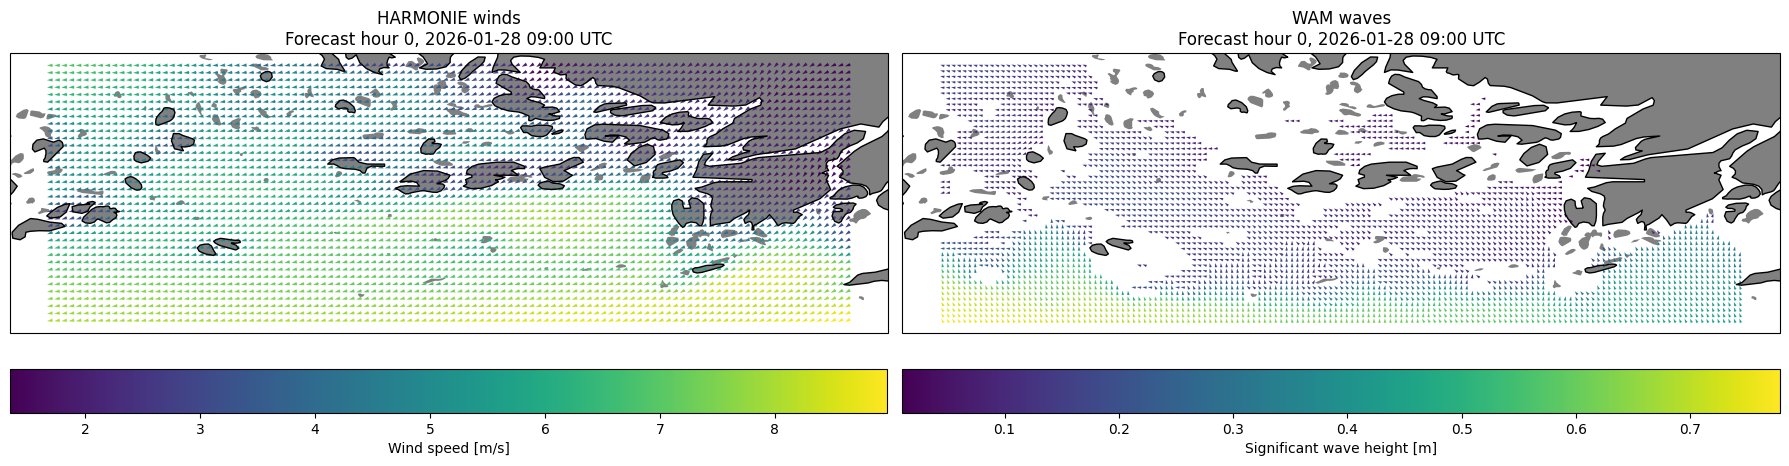

In [18]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import numpy as np

# -----------------------------
# Load datasets
# -----------------------------
ds = xr.open_dataset("data/harmonie_wind_latest_48h.nc")
ds_wam = xr.open_dataset("data/wam_wave_latest_48h.grib2", engine="cfgrib")

hour = 0  # forecast hour index
ds_slice = ds.isel(time=hour)
forecast_time = pd.to_datetime(ds_slice['time'].values)

# WAM slice at same forecast hour
ds_wam_slice = ds_wam.isel(step=hour)

# -----------------------------
# Create figure with 2 stacked subplots
# -----------------------------
fig, axes = plt.subplots(
    1, 2, figsize=(18, 18),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# -----------------------------
# Panel 1: HARMONIE winds (arrows sized to grid)
# -----------------------------
ax = axes[0]
ax.add_feature(cfeature.LAND, facecolor='gray')
ax.add_feature(cfeature.COASTLINE)

# Extract wind components and coordinates
u_wind = ds_slice['eastward_wind_23'].values
v_wind = ds_slice['northward_wind_24'].values
lon_wind = ds_slice['lon'].values
lat_wind = ds_slice['lat'].values

# Normalize to unit vectors (all arrows same length)
norm = np.sqrt(u_wind**2 + v_wind**2)
u_unit = u_wind / norm
v_unit = v_wind / norm

# Compute grid spacing from 1D coordinates
dx = np.mean(np.diff(lon_wind))
dy = np.mean(np.diff(lat_wind))
arrow_length = min(dx, dy) * 0.8

# Scale vectors to grid spacing
u_plot = u_unit * arrow_length
v_plot = v_unit * arrow_length

# Create 2D coordinates for quiver
lon2d, lat2d = np.meshgrid(lon_wind, lat_wind)

# Quiver plot
q = ax.quiver(
    lon2d, lat2d, u_plot, v_plot, np.sqrt(u_wind**2 + v_wind**2),  # color by wind speed
    angles='xy', scale_units='xy', scale=1,
    cmap='viridis', pivot='middle', width=0.003
)

# Colorbar for wind speed
cbar = fig.colorbar(q, ax=ax, orientation='horizontal', pad=0.02)
cbar.set_label('Wind speed [m/s]')

ax.set_title(f"HARMONIE winds\nForecast hour {hour}, {forecast_time:%Y-%m-%d %H:%M UTC}")

# -----------------------------
# Panel 2: WAM waves (direction & height, arrows sized to grid)
# -----------------------------
ax = axes[1]
ax.add_feature(cfeature.LAND, facecolor='gray')
ax.add_feature(cfeature.COASTLINE)

# Extract WAM variables
swh = ds_wam_slice['swh'].values
mwd = ds_wam_slice['mwd'].values
lon = ds_wam_slice['longitude'].values
lat = ds_wam_slice['latitude'].values

# Convert wave direction to radians (toward propagation)
angle_rad = np.deg2rad((mwd + 180) % 360)
u = np.sin(angle_rad)
v = np.cos(angle_rad)

# Normalize to unit vectors
norm = np.sqrt(u**2 + v**2)
u_unit = u / norm
v_unit = v / norm

# Grid spacing
dx = np.mean(np.diff(lon))
dy = np.mean(np.diff(lat))
arrow_length = min(dx, dy) * 0.8

# Scale vectors
u_plot = u_unit * arrow_length
v_plot = v_unit * arrow_length

# 2D coordinates
lon2d, lat2d = np.meshgrid(lon, lat)

# Quiver plot: arrows show direction, color shows swh
q = ax.quiver(
    lon2d, lat2d, u_plot, v_plot, swh,
    angles='xy', scale_units='xy', scale=1,
    cmap='viridis', pivot='middle', width=0.003
)

# Colorbar for wave height
cbar = fig.colorbar(q, ax=ax, orientation='horizontal', pad=0.02)
cbar.set_label('Significant wave height [m]')

ax.set_title(f"WAM waves\nForecast hour {hour}, {forecast_time:%Y-%m-%d %H:%M UTC}")

plt.tight_layout()
plt.show()


In [43]:
# !pip install -- owslib
from owslib.wfs import WebFeatureService

# Connect to FMI WFS
url = "http://opendata.fmi.fi/wfs?service=WFS&request=getCapabilities"
wfs = WebFeatureService(url=url, version='2.0.0')

# Loop through layers to inspect titles and abstracts
for layer_name, layer_meta in wfs.contents.items():
    print("Layer:", layer_name)
    print("  Title:", layer_meta.title)
    print("  Abstract:", layer_meta.abstract)
    print()


Layer: BsWfs:BsWfsElement
  Title: Observations and forecasts
  Abstract: Timeseries data of surface weather observations from meteorological and road
        weather observation stations, as well as air quality measurement stations, as well as
        point forecasts of the basic surface weather parameters for the major towns and cities
        in Finland. Each of these features contains measured or predicted atmospheric property
        values from one station over the requested time period and resolution in 'simple feature' format.

Layer: ef:EnvironmentalMonitoringFacility
  Title: Facilities belonging to environmental observation station networks
  Abstract: Includes operational weather observation stations, road-weather stations,
        weather radars, air quality observing stations, mareograms and wave buoys beloging
        to the FMI observation network or being distributed via FMI download service (air quality).

Layer: ef:EnvironmentalMonitoringNetwork
  Title: Environmenta

In [48]:
from owslib.wfs import WebFeatureService

url = "http://opendata.fmi.fi/wfs?service=WFS&version=2.0.0"
wfs = WebFeatureService(url=url, version="2.0.0")

response = wfs.getfeature(
    storedQueryID="fmi::forecast::harmonie::hybrid::grid",
    storedQueryParams={
        "starttime": "2023-07-15T00:00:00Z",
        "endtime":   "2023-07-15T23:59:00Z",
        "bbox":      "20.4,59.7,22.9,60.5"  # Your area
    },
    outputFormat="application/gml+xml; version=3.2"
)

data = response.read()
with open("harmonie_forecast_past.gml", "wb") as f:
    f.write(data)

print("Saved past forecast GML")


Saved past forecast GML


In [49]:
from owslib.wfs import WebFeatureService

wfs = WebFeatureService(url="http://opendata.fmi.fi/wfs?service=WFS&version=2.0.0", version="2.0.0")

for sq in wfs.storedqueries:
    print(sq.id, "-", sq.title)


ecmwf::forecast::pressure::grid - ECMWF Pressure Grid
ecmwf::forecast::surface::cities::multipointcoverage - ECMWF weather forecast for cities in Finland as multipointcoverage
ecmwf::forecast::surface::cities::simple - ECMWF weather forecast for cities in Finland as simple features
ecmwf::forecast::surface::cities::timevaluepair - ECMWF weather forecast for cities in Finland as time value pairs
ecmwf::forecast::surface::finland::grid - ECMWF surface level weather forecast for Finland as a grid.
ecmwf::forecast::surface::grid - ECMWF Surface Grid
ecmwf::forecast::surface::obsstations::multipointcoverage - ECMWF weather forecast for observation stations as multipointcoverage.
ecmwf::forecast::surface::obsstations::simple - ECMWF weather forecast for observation stations as simple feature.
ecmwf::forecast::surface::obsstations::timevaluepair - ECMWF weather forecast for observation stations as time value pairs.
ecmwf::forecast::surface::point::multipointcoverage - ECMWF Point Weather Fore

In [50]:
from owslib.wfs import WebFeatureService
import xml.etree.ElementTree as ET
from datetime import datetime, timedelta

# Connect to FMI WFS
wfs = WebFeatureService(
    url="http://opendata.fmi.fi/wfs?service=WFS&version=2.0.0",
    version="2.0.0"
)

# Parameters
stored_query = "fmi::forecast::meps::surface::grid"
bbox = "20.4,59.7,22.9,60.5"  # Finland region of interest
start_date = datetime(2023, 7, 10)  # first day to check
end_date   = datetime(2023, 7, 15)  # last day to check

# Loop through each day
current_date = start_date
all_file_urls = []

while current_date <= end_date:
    starttime = current_date.strftime("%Y-%m-%dT00:00:00Z")
    endtime   = current_date.strftime("%Y-%m-%dT23:59:00Z")

    print(f"Requesting MEPS surface forecast for {current_date.date()}...")

    response = wfs.getfeature(
        storedQueryID=stored_query,
        storedQueryParams={
            "starttime": starttime,
            "endtime": endtime,
            "bbox": bbox
        },
        outputFormat="application/gml+xml; version=3.2"
    )

    # Parse GML
    gml_data = response.read()
    root = ET.fromstring(gml_data)

    # GML namespace for fileReference
    ns = {"gml": "http://www.opengis.net/gml/3.2"}

    # Extract fileReference URLs
    file_urls = [elem.text for elem in root.findall(".//gml:fileReference", ns)]
    if file_urls:
        print(f"  Found {len(file_urls)} files")
        all_file_urls.extend(file_urls)
    else:
        print("  No files found for this date.")

    current_date += timedelta(days=1)

# Print all URLs
print("\nAll available gridded forecast files in range:")
for url in all_file_urls:
    print(url)


Requesting MEPS surface forecast for 2023-07-10...
  No files found for this date.
Requesting MEPS surface forecast for 2023-07-11...
  No files found for this date.
Requesting MEPS surface forecast for 2023-07-12...
  No files found for this date.
Requesting MEPS surface forecast for 2023-07-13...
  No files found for this date.
Requesting MEPS surface forecast for 2023-07-14...
  No files found for this date.
Requesting MEPS surface forecast for 2023-07-15...
  No files found for this date.

All available gridded forecast files in range:
